In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/friday-workinghours-afternoon-ddos-pcap-iscx-csv/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [3]:
# 📦 Essential Libraries for DDoS Forecasting (Time Series + Classification)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ✅ Machine Learning & Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# ✅ Deep Learning (LSTM)
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam

# 🔁 Environment Info (for reproducibility)
print("✅ TensorFlow version:", tf.__version__)
print("✅ NumPy version:", np.__version__)
print("✅ Pandas version:", pd.__version__)

✅ TensorFlow version: 2.18.0
✅ NumPy version: 1.26.4
✅ Pandas version: 2.2.3


In [4]:
df = pd.read_csv('/kaggle/input/friday-workinghours-afternoon-ddos-pcap-iscx-csv/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

In [5]:
df.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [6]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 85 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flow ID                       225745 non-null  object 
 1    Source IP                    225745 non-null  object 
 2    Source Port                  225745 non-null  int64  
 3    Destination IP               225745 non-null  object 
 4    Destination Port             225745 non-null  int64  
 5    Protocol                     225745 non-null  int64  
 6    Timestamp                    225745 non-null  object 
 7    Flow Duration                225745 non-null  int64  
 8    Total Fwd Packets            225745 non-null  int64  
 9    Total Backward Packets       225745 non-null  int64  
 10  Total Length of Fwd Packets   225745 non-null  int64  
 11   Total Length of Bwd Packets  225745 non-null  int64  
 12   Fwd Packet Length Max        225745 non-nul

In [7]:
train_columns = list(df.columns)
df.describe()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,225745.000000,225745.00000,225745.000000,2.257450e+05,225745.000000,225745.000000,225745.000000,2.257450e+05,225745.000000,225745.000000,...,225745.000000,225745.000000,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05
mean,38257.568402,8879.61946,7.600288,1.624165e+07,4.874916,4.572775,939.463346,5.960477e+03,538.535693,27.882221,...,3.311497,21.482753,1.848261e+05,1.293436e+04,2.080849e+05,1.776201e+05,1.032214e+07,3.611943e+06,1.287813e+07,7.755355e+06
std,23057.302075,19754.64740,3.881586,3.152437e+07,15.422874,21.755356,3249.403484,3.921834e+04,1864.128991,163.324159,...,12.270018,4.166799,7.979250e+05,2.102737e+05,9.002350e+05,7.842602e+05,2.185303e+07,1.275689e+07,2.692126e+07,1.983109e+07
min,0.000000,0.00000,0.000000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,18990.000000,80.00000,6.000000,7.118000e+04,2.000000,1.000000,26.000000,0.000000e+00,6.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,49799.000000,80.00000,6.000000,1.452333e+06,3.000000,4.000000,30.000000,1.640000e+02,20.000000,0.000000,...,2.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,58296.000000,80.00000,6.000000,8.805237e+06,5.000000,5.000000,63.000000,1.160100e+04,34.000000,6.000000,...,4.000000,20.000000,1.878000e+03,0.000000e+00,1.878000e+03,1.862000e+03,8.239725e+06,0.000000e+00,8.253838e+06,7.422849e+06
max,65534.000000,65532.00000,17.000000,1.199999e+08,1932.000000,2942.000000,183012.000000,5.172346e+06,11680.000000,1472.000000,...,1931.000000,52.000000,1.000000e+08,3.950000e+07,1.000000e+08,1.000000e+08,1.200000e+08,6.530000e+07,1.200000e+08,1.200000e+08


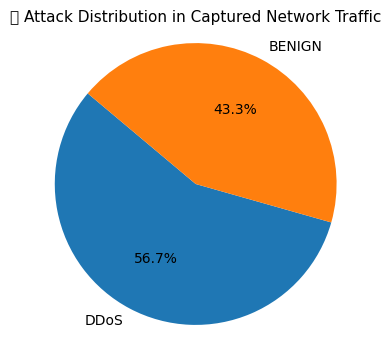

In [8]:
# 📊 Function to Visualize DDoS Attack Label Distribution

def plot_attack_distribution(df, label_column=' Label'):
    """
    Visualizes the distribution of attack types or binary labels in the dataset.
    Useful for understanding class imbalance.
    """
    label_counts = df[label_column].value_counts()
    labels = label_counts.index
    sizes = label_counts.values

    plt.figure(figsize=(4, 4))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 10})
    plt.title('🛡️ Attack Distribution in Captured Network Traffic', fontsize=11)
    plt.axis('equal')  # Ensures pie is a circle
    plt.show()

plot_attack_distribution(df)

In [9]:
def preprocess_timestamps(df, timestamp_col=' Timestamp'):
    df.columns = [col.strip() for col in df.columns]  # Clean column names
    if timestamp_col in df.columns:
        df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors='coerce')
        df.sort_values(by=timestamp_col, inplace=True)
        df.dropna(subset=[timestamp_col], inplace=True)  # Drop invalid timestamps
        df.reset_index(drop=True, inplace=True)
        print("✅ Timestamp normalized and dataset sorted by time.")
    return df

In [10]:
def plot_traffic_volume(df):
    traffic = df.groupby('Timestamp').size()
    plt.figure(figsize=(12, 5))
    traffic.plot(color='steelblue')
    plt.title('📈 Network Traffic Volume Over Time')
    plt.xlabel('Timestamp')
    plt.ylabel('Connections')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [11]:
# DDoS vs Benign Trend with Dotted Markers
import matplotlib.dates as mdates

def plot_label_timeseries(df, timestamp_col='Timestamp', interval='10S'):
    # Ensure the Timestamp column is datetime and set as index
    df = df.copy()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors='coerce')
    df.dropna(subset=[timestamp_col], inplace=True)
    df.set_index(timestamp_col, inplace=True)

    # Resample label counts
    benign = df[df['Label'] == 'BENIGN'].resample(interval).size()
    ddos = df[df['Label'] != 'BENIGN'].resample(interval).size()

    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(benign.index, benign.values, linestyle=':', marker='o', color='green', label='Benign', alpha=0.7, markersize=3)
    plt.plot(ddos.index, ddos.values, linestyle=':', marker='o', color='red', label='DDoS', alpha=0.7, markersize=3)

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.gcf().autofmt_xdate()

    plt.title('⏳ Benign vs. DDoS Connection Trends (Every 10 Seconds)')
    plt.xlabel('Time (HH:MM)')
    plt.ylabel('Connection Count')
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

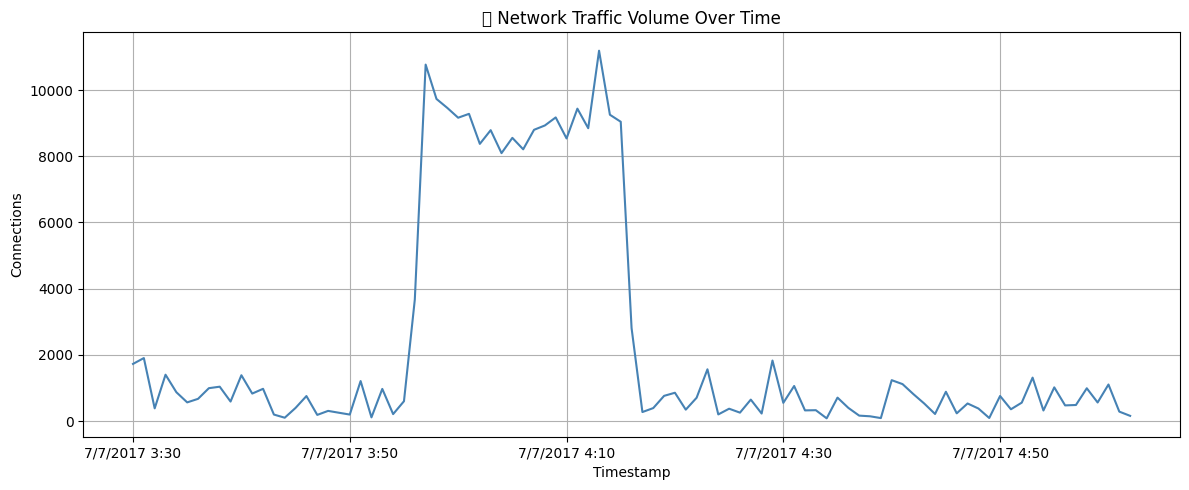

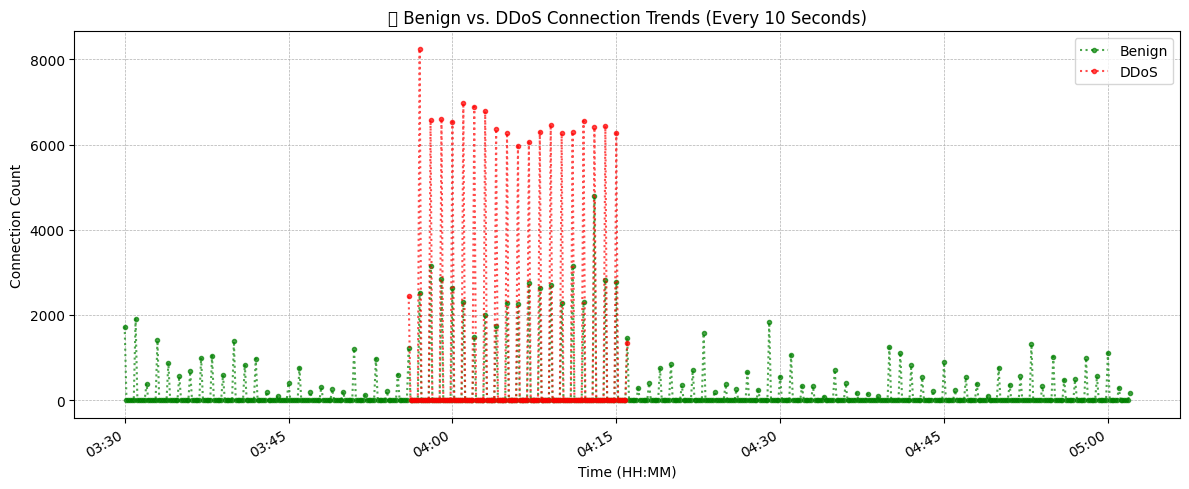

In [12]:
ddos_data = preprocess_timestamps(df)
plot_traffic_volume(ddos_data)
plot_label_timeseries(ddos_data)

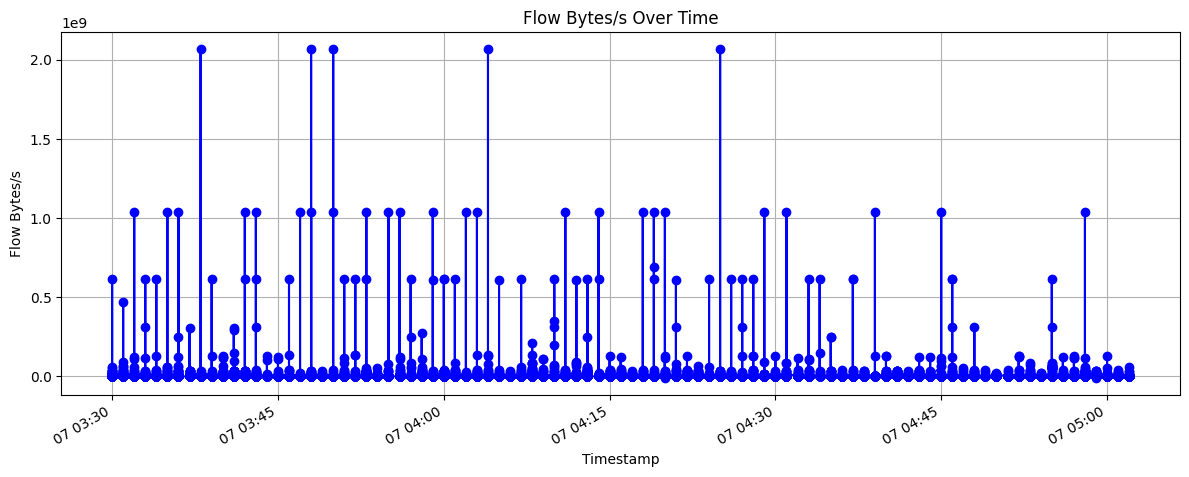

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(pd.to_datetime(ddos_data['Timestamp'], errors='coerce'),
         pd.to_numeric(ddos_data['Flow Bytes/s'], errors='coerce'),
         marker='o', linestyle='-', color='blue')

plt.title('Flow Bytes/s Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Flow Bytes/s')
plt.grid(True)
plt.tight_layout()
plt.gcf().autofmt_xdate()
plt.show()

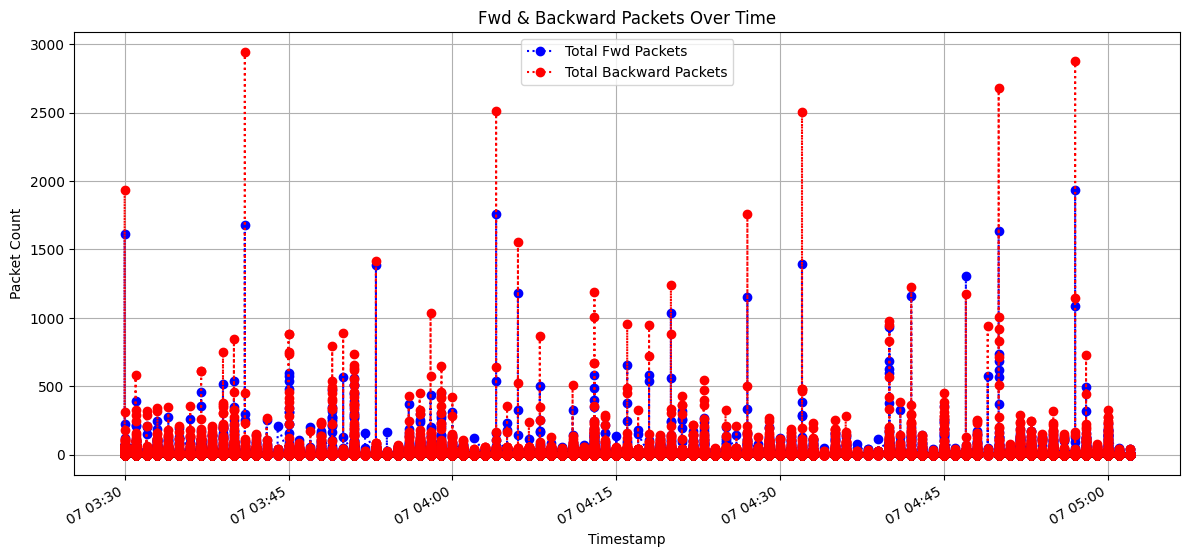

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(ddos_data['Timestamp'], errors='coerce'),
         pd.to_numeric(ddos_data['Total Fwd Packets'], errors='coerce'),
         color='blue', marker='o', linestyle=':', label='Total Fwd Packets')

plt.plot(pd.to_datetime(ddos_data['Timestamp'], errors='coerce'),
         pd.to_numeric(ddos_data['Total Backward Packets'], errors='coerce'),
         color='red', marker='o', linestyle=':', label='Total Backward Packets')

plt.title('Fwd & Backward Packets Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Packet Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.gcf().autofmt_xdate()
plt.show()

In [15]:
def full_feature_distribution_analysis(ddos_data):
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Strip column names to prevent future issues
    ddos_data.columns = ddos_data.columns.str.strip()

    # Binary columns
    binary_columns = ddos_data.columns[ddos_data.nunique() == 2].tolist()

    # Plot binary column distributions
    fig, ax = plt.subplots(3, 3, figsize=(15, 15))
    ax = ax.flatten()
    for i, column in enumerate(binary_columns[:9]):  # Limit to first 9 to fit plot
        sns.countplot(data=ddos_data, x=column, ax=ax[i])
        ax[i].set_title(f'Distribution of {column}')
        ax[i].set_xlabel(column)
        ax[i].set_ylabel('Count')
    plt.tight_layout()
    plt.show()

    # Protocol distribution
    protocol_map = {6: 'TCP', 17: 'UDP', 0: 'HOPOPT'}
    protocol_counts = ddos_data['Protocol'].value_counts()
    protocol_counts.index = protocol_counts.index.map(protocol_map)

    plt.figure(figsize=(5, 4))
    protocol_counts.plot(kind='pie', autopct='%1.3f%%', startangle=140, colors=['skyblue', 'lightgreen', 'lightcoral'])
    plt.title('Protocol Distribution')
    plt.ylabel('')
    plt.axis('equal')
    plt.show()

    # Discrete non-binary and continuous variable separation
    discrete_vars = [col for col in ddos_data.select_dtypes(include='int64').columns if col not in binary_columns]
    continuous_vars = ddos_data.select_dtypes(include='float64').columns.tolist()

    return {
        "binary_columns": binary_columns,
        "discrete_vars": discrete_vars,
        "continuous_vars": continuous_vars
    }

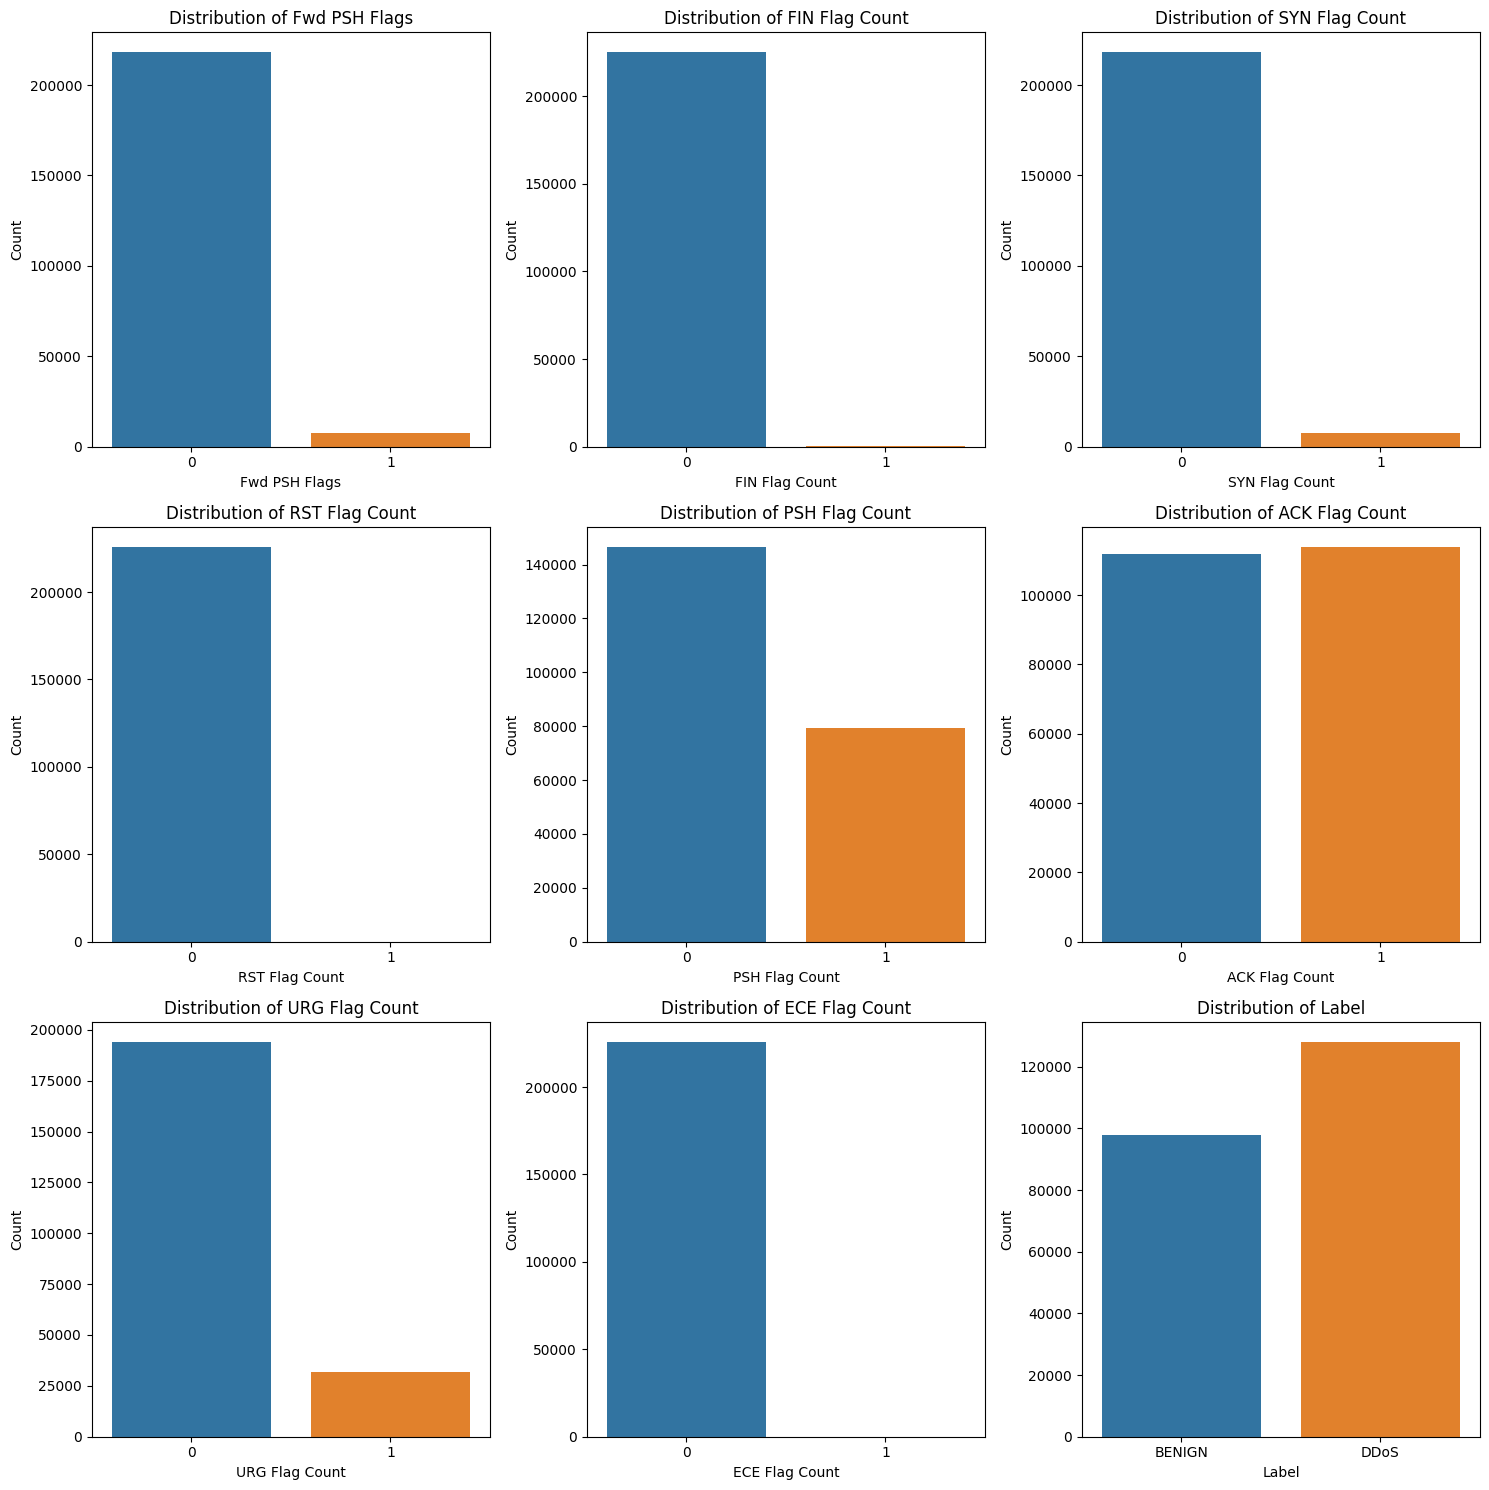

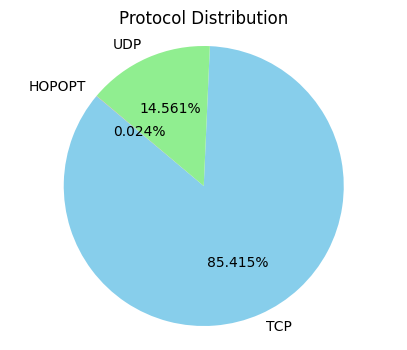

In [16]:
result = full_feature_distribution_analysis(ddos_data)

In [17]:
# Find constant columns (those with only one unique value)
constant_columns = ddos_data.columns[ddos_data.nunique() == 1]

# Show column names and how many constant columns found
print(f"Constant columns to drop ({len(constant_columns)}):\n{list(constant_columns)}")

Constant columns to drop (10):
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [18]:
# Drop known redundant and constant columns
def dropping_const_and_red_columns(df):
    df.columns = df.columns.str.strip()  # Clean column names
    df.drop(['Flow ID', 'Fwd Header Length.1'], axis=1, inplace=True)
    df.drop(columns=constant_columns, inplace=True)

dropping_const_and_red_columns(ddos_data)

In [19]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

def encode_label_col(df):
    df.columns = df.columns.str.strip()
    df['Label'] = label_encoder.fit_transform(df['Label'])

encode_label_col(ddos_data)

In [20]:
def encoding_ip_srv_dst(df):
    all_ip = pd.concat([df['Source IP'], df['Destination IP']])
    label_encoder.fit(all_ip)
    df['Source IP'] = label_encoder.transform(df['Source IP'])
    df['Destination IP'] = label_encoder.transform(df['Destination IP'])

encoding_ip_srv_dst(ddos_data)

In [21]:
ddos_data_cp = ddos_data.drop('Timestamp', axis=1)

In [22]:
ddos_data_cp.corr()

,Source IP,Source Port,Destination IP,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
Source IP,1.000000,-0.364323,-0.010057,0.454587,0.298156,-0.040601,0.020113,0.038123,0.210294,-0.037069,...,0.289566,-0.022408,0.079552,0.013414,-0.037990,-0.084251,-0.067886,-0.090827,-0.062509,-0.752707
Source Port,-0.364323,1.000000,0.292387,-0.727093,0.193702,0.066677,0.046492,-0.005598,-0.376220,0.053109,...,0.051752,0.035426,0.015362,0.037363,0.034631,0.051217,0.040340,0.055066,0.037903,0.388721
Destination IP,-0.010057,0.292387,1.000000,-0.374056,0.003325,-0.045646,0.054167,0.011315,-0.209284,0.026897,...,0.166936,-0.036924,0.081243,0.006315,-0.050291,-0.111537,-0.082802,-0.118200,-0.085869,0.019534
Destination Port,0.454587,-0.727093,-0.374056,1.000000,-0.183045,0.107038,-0.044270,0.008321,0.553843,-0.066648,...,-0.074278,0.061313,-0.026592,0.043156,0.066356,0.132272,0.110687,0.144428,0.095687,-0.509798
Protocol,0.298156,0.193702,0.003325,-0.183045,1.000000,-0.194691,-0.077461,-0.052777,-0.107639,-0.060670,...,0.474116,-0.096252,-0.033096,-0.099233,-0.092237,-0.169636,-0.116058,-0.176677,-0.133858,-0.471904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Idle Mean,-0.084251,0.051217,-0.111537,0.132272,-0.169636,0.871855,0.110787,0.065554,0.261110,0.042256,...,-0.139772,0.595859,0.022025,0.531538,0.602021,1.000000,0.420170,0.952585,0.910822,0.087114
Idle Std,-0.067886,0.040340,-0.082802,0.110687,-0.116058,0.630604,0.056807,0.028627,0.216771,0.020081,...,-0.099363,-0.057820,-0.003866,-0.055222,-0.058847,0.420170,1.000000,0.676276,0.008218,0.078023
Idle Max,-0.090827,0.055066,-0.118200,0.144428,-0.176677,0.919199,0.109429,0.062932,0.284694,0.041055,...,-0.146873,0.464725,0.017842,0.413812,0.469089,0.952585,0.676276,1.000000,0.742109,0.096775
Idle Min,-0.062509,0.037903,-0.085869,0.095687,-0.133858,0.672003,0.094747,0.058056,0.188569,0.036789,...,-0.109090,0.682722,0.024496,0.609839,0.690201,0.910822,0.008218,0.742109,1.000000,0.061243


In [23]:
correlation_matrix = ddos_data_cp.corr().abs()

# Get upper triangle of correlation matrix (excluding self-correlations)
upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Find pairs with correlation above threshold
threshold = 0.9
correlated_features = [(col1, col2, upper.loc[col1, col2])
                       for col1 in upper.columns
                       for col2 in upper.index
                       if upper.loc[col1, col2] > threshold]

# Print result
for feature1, feature2, corr_value in correlated_features:
    print(f"{feature1} and {feature2} are highly correlated: {corr_value}")

Flow Duration and Flow IAT Max are highly correlated: 0.9202572641153036
Flow Duration and Fwd IAT Total are highly correlated: 0.9970539718291673
Flow Duration and Fwd IAT Max are highly correlated: 0.917945815778127
Flow Duration and Idle Max are highly correlated: 0.9191990945209687
Total Fwd Packets and Total Backward Packets are highly correlated: 0.9567137090959984
Total Fwd Packets and Total Length of Bwd Packets are highly correlated: 0.9384698040256881
Total Fwd Packets and Fwd Header Length are highly correlated: 0.968433776732758
Total Fwd Packets and Bwd Header Length are highly correlated: 0.9287367502694539
Total Fwd Packets and Subflow Fwd Packets are highly correlated: 1.0
Total Fwd Packets and Subflow Bwd Packets are highly correlated: 0.9567137090959984
Total Fwd Packets and Subflow Bwd Bytes are highly correlated: 0.9384698040256881
Total Backward Packets and Total Length of Bwd Packets are highly correlated: 0.9704220020372479
Total Backward Packets and Fwd Header L

In [24]:
# Step 1: Drop weakly correlated features from Set 1
low_corr_set1 = ['Flow Duration', 'Flow IAT Max', 'Fwd IAT Total', 'Idle Max']
ddos_data.drop(columns=low_corr_set1, inplace=True)

# Step 2: Drop weakly correlated features from Set 2
low_corr_set2 = ['Total Fwd Packets', 'Total Backward Packets', 'Total Length of Bwd Packets',
                 'Fwd Header Length', 'Subflow Fwd Packets', 'Subflow Bwd Packets', 'Subflow Bwd Bytes']
ddos_data.drop(columns=low_corr_set2, inplace=True)

# Step 3: Drop redundant highly correlated features (perfectly correlated pairs)
# Total Length of Fwd Packets ≈ Subflow Fwd Bytes (keep one)
# Fwd Packet Length Mean ≈ Avg Fwd Segment Size (keep one)
# Total Length of Bwd Packets ≈ Subflow Bwd Bytes (already dropped)
ddos_data.drop(columns=['Fwd PSH Flags', 'RST Flag Count', 'Subflow Fwd Bytes', 'Fwd Packet Length Mean'], inplace=True)

# Step 4: Drop lower-contributing FWD packet length features
ddos_data.drop(columns=['Fwd Packet Length Max', 'Fwd Packet Length Std'], inplace=True)

# Step 5: Drop highly correlated backward features except one
# Keep: ' Avg Bwd Segment Size' (same as Bwd Packet Length Mean)
ddos_data.drop(columns=['Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Bwd Packet Length Std'], inplace=True)

# Step 6: Drop weakly contributing IAT & Idle features
ddos_data.drop(columns=['Flow IAT Mean', 'Flow IAT Std', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
                        'Idle Mean', 'Fwd IAT Min', 'Bwd IAT Min'], inplace=True)

# Step 7: Drop lower contributing general packet metrics (keep strongest)
ddos_data.drop(columns=['Bwd IAT Std', 'Bwd IAT Max', 'Max Packet Length',
                        'Packet Length Std', 'Packet Length Variance', 'Average Packet Size'], inplace=True)

# Step 8: Drop Active metrics with very low correlation
ddos_data.drop(columns=['Active Mean', 'Active Max'], inplace=True)

In [25]:
ddos_data.sort_index(inplace=True)
# 1. Convert ' Timestamp' column to datetime format
ddos_data['Timestamp'] = pd.to_datetime(ddos_data['Timestamp'], errors='coerce')

# 2. Drop rows where timestamp conversion failed (optional but recommended)
ddos_data.dropna(subset=['Timestamp'], inplace=True)

# 3. Set the ' Timestamp' column as the index
ddos_data.set_index('Timestamp', inplace=True)

ddos_data.corr()

,Source IP,Source Port,Destination IP,Destination Port,Protocol,Total Length of Fwd Packets,Fwd Packet Length Min,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,...,Avg Bwd Segment Size,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Std,Active Min,Idle Std,Idle Min,Label
Source IP,1.000000,-0.364323,-0.010057,0.454587,0.298156,0.210294,0.123614,0.235521,0.030494,0.175986,...,-0.460018,0.032815,0.165985,-0.011737,0.289566,0.079552,-0.037990,-0.067886,-0.062509,-0.752707
Source Port,-0.364323,1.000000,0.292387,-0.727093,0.193702,-0.376220,-0.183577,0.149612,-0.010242,-0.129796,...,0.307940,0.059325,-0.028756,0.053464,0.051752,0.015362,0.034631,0.040340,0.037903,0.388721
Destination IP,-0.010057,0.292387,1.000000,-0.374056,0.003325,-0.209284,-0.129450,-0.005483,0.001423,0.014954,...,0.045612,0.301908,0.162807,0.041041,0.166936,0.081243,-0.050291,-0.082802,-0.085869,0.019534
Destination Port,0.454587,-0.727093,-0.374056,1.000000,-0.183045,0.553843,0.207158,-0.119517,0.025816,0.142714,...,-0.351014,-0.112897,0.027405,-0.051366,-0.074278,-0.026592,0.066356,0.110687,0.095687,-0.509798
Protocol,0.298156,0.193702,0.003325,-0.183045,1.000000,-0.107639,0.038159,0.725937,0.010361,-0.000067,...,-0.288596,-0.217913,-0.057460,-0.074932,0.474116,-0.033096,-0.092237,-0.116058,-0.133858,-0.471904
Total Length of Fwd Packets,0.210294,-0.376220,-0.209284,0.553843,-0.107639,1.000000,0.004453,-0.073738,0.001499,-0.031237,...,-0.199152,0.060274,0.024830,0.161399,-0.048262,0.106051,0.171280,0.216771,0.188569,-0.319693
Fwd Packet Length Min,0.123614,-0.183577,-0.129450,0.207158,0.038159,0.004453,1.000000,0.033618,-0.000616,-0.011950,...,-0.131073,-0.084467,-0.013014,-0.040054,-0.000325,-0.010325,-0.035780,-0.048230,-0.021718,-0.180094
Bwd Packet Length Min,0.235521,0.149612,-0.005483,-0.119517,0.725937,-0.073738,0.033618,1.000000,0.013258,-0.015126,...,-0.212724,-0.164156,-0.038517,-0.060982,0.343618,-0.016336,-0.069898,-0.092328,-0.107084,-0.365667
Flow Bytes/s,0.030494,-0.010242,0.001423,0.025816,0.010361,0.001499,-0.000616,0.013258,1.000000,0.295420,...,-0.022963,-0.001523,-0.003410,-0.003713,0.021245,-0.002126,-0.007847,-0.009814,-0.013555,-0.035545
Flow Packets/s,0.175986,-0.129796,0.014954,0.142714,-0.000067,-0.031237,-0.011950,-0.015126,0.295420,1.000000,...,-0.096812,-0.017841,0.005567,-0.021330,0.062436,-0.007610,-0.028023,-0.035033,-0.048388,-0.139922


In [26]:
# Compute the correlation matrix
correlation_matrix = ddos_data.corr()

# Select the correlation values of the 'Label' column
if 'Label' in correlation_matrix.columns:
    label_correlation = correlation_matrix['Label']
    print(label_correlation)
else:
    print("'Label' column not found in the correlation matrix.")

Source IP                     -0.752707
Source Port                    0.388721
Destination IP                 0.019534
Destination Port              -0.509798
Protocol                      -0.471904
Total Length of Fwd Packets   -0.319693
Fwd Packet Length Min         -0.180094
Bwd Packet Length Min         -0.365667
Flow Bytes/s                  -0.035545
Flow Packets/s                -0.139922
Flow IAT Min                  -0.038680
Bwd IAT Total                 -0.318679
Bwd IAT Mean                  -0.208595
Bwd Header Length             -0.076183
Fwd Packets/s                 -0.129418
Bwd Packets/s                 -0.090383
Min Packet Length             -0.427396
Packet Length Mean             0.454283
FIN Flag Count                -0.054560
SYN Flag Count                -0.212189
PSH Flag Count                 0.247740
ACK Flag Count                 0.096975
URG Flag Count                -0.463190
ECE Flag Count                -0.012519
Down/Up Ratio                 -0.305344


In [27]:
# Select numeric columns only
numeric_cols = ddos_data.select_dtypes(include=['number'])
# Then filter non-binary numeric columns
non_binary_numeric_cols = numeric_cols.columns[numeric_cols.nunique() > 2]

In [28]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Initialize scaler
scaler = StandardScaler()

# Identify non-binary columns (more than 2 unique values)
non_binary_columns = ddos_data.columns[ddos_data.nunique() > 2]

# Check for problematic values in numerical columns
is_infinite = np.any(np.isinf(ddos_data[non_binary_columns]), axis=0)
is_large = np.any(np.abs(ddos_data[non_binary_columns]) > np.finfo(np.float64).max, axis=0)

# Identify columns with issues
columns_with_issues = non_binary_columns[is_infinite | is_large]
print("Columns with Infinite or Extremely Large Values:", columns_with_issues)

# Drop problematic columns
ddos_data.drop(columns=columns_with_issues, inplace=True)

# Re-identify non-binary columns after dropping
non_binary_columns = ddos_data.columns[ddos_data.nunique() > 2]

# Scale remaining numerical features
def scale_num_features(df):
    df[non_binary_columns] = scaler.fit_transform(df[non_binary_columns])

scale_num_features(ddos_data)

# Final feature set to be used for model training
final_columns = ddos_data.columns

Columns with Infinite or Extremely Large Values: Index(['Flow Bytes/s', 'Flow Packets/s'], dtype='object')


In [29]:
# Parameters: how many past and future steps to consider
n_past = 10     # Look-back window (e.g., 10 time steps of historical data)
n_future = 1    # Predicting 1 step ahead

# Initialize sequences for model training
trainX, trainY = [], []

# Sliding window over the dataset
for i in range(n_past, len(ddos_data) - n_future + 1):
    # Past window of features
    x_slice = ddos_data.iloc[i - n_past:i, :].values
    # Future label (binary: DDoS or not)
    y_slice = ddos_data.iloc[i + n_future - 1]['Label']

    trainX.append(x_slice)
    trainY.append(y_slice)

# Convert to NumPy arrays
trainX = np.array(trainX)
trainY = np.array(trainY).reshape(-1, 1)  # Ensure 2D shape for compatibility

# Confirm the data shapes
print(f"trainX shape = {trainX.shape}")  # (samples, time_steps, features)
print(f"trainY shape = {trainY.shape}")  # (samples, 1)

trainX shape = (225735, 10, 34)
trainY shape = (225735, 1)


In [174]:
# Define the LSTM-based sequential model
model = Sequential([
    LSTM(256, return_sequences=True, input_shape=(trainX.shape[1], trainX.shape[2])),
    LSTM(128, return_sequences=True),
    LSTM(64, return_sequences=True),
    LSTM(32, return_sequences=True),
    LSTM(16, return_sequences=False),
    Dropout(0.01),
    Dense(1, activation='sigmoid')
])

# Compile the model with Adam optimizer and binary cross-entropy loss
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

# Display the model structure
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_75 (LSTM)                       │ (None, 10, 256)             │         297,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_76 (LSTM)                       │ (None, 10, 128)             │         197,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_77 (LSTM)                       │ (None, 10, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_78 (LSTM)                       │ (None, 10, 32)              │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_79 (LSTM)                       │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_50 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 560,081 (2.14 MB)

 Trainable params: 560,081 (2.14 MB)

 Non-trainable params: 0 (0.00 B)

In [171]:
history_log = model.fit(
    trainX, trainY,
    epochs=24,
    batch_size=1024,
    validation_split=0.2,
    verbose=2,
    shuffle=False
)

Epoch 1/24
177/177 - 11s - 61ms/step - accuracy: 0.9743 - loss: 0.4109 - val_accuracy: 0.9669 - val_loss: 0.2899
Epoch 2/24
177/177 - 4s - 25ms/step - accuracy: 0.9960 - loss: 0.1617 - val_accuracy: 0.9951 - val_loss: 0.1655
Epoch 3/24
177/177 - 4s - 25ms/step - accuracy: 0.9978 - loss: 0.1036 - val_accuracy: 0.9970 - val_loss: 0.1123
Epoch 4/24
177/177 - 4s - 25ms/step - accuracy: 0.9980 - loss: 0.0738 - val_accuracy: 0.9976 - val_loss: 0.0799
Epoch 5/24
177/177 - 5s - 26ms/step - accuracy: 0.9980 - loss: 0.0557 - val_accuracy: 0.9979 - val_loss: 0.0602
Epoch 6/24
177/177 - 5s - 26ms/step - accuracy: 0.9980 - loss: 0.0445 - val_accuracy: 0.9980 - val_loss: 0.0477
Epoch 7/24
177/177 - 5s - 26ms/step - accuracy: 0.9980 - loss: 0.0370 - val_accuracy: 0.9980 - val_loss: 0.0391
Epoch 8/24
177/177 - 5s - 26ms/step - accuracy: 0.9981 - loss: 0.0317 - val_accuracy: 0.9981 - val_loss: 0.0333
Epoch 9/24
177/177 - 5s - 26ms/step - accuracy: 0.9981 - loss: 0.0280 - val_accuracy: 0.9980 - val_loss

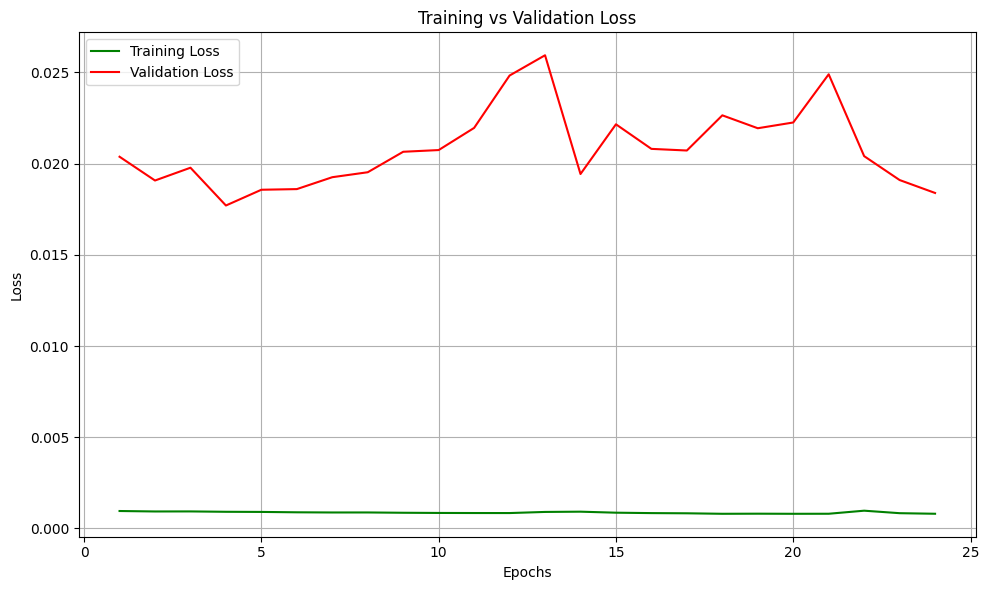

In [165]:
import matplotlib.pyplot as plt

loss = history_log.history['loss']
val_loss = history_log.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'g-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

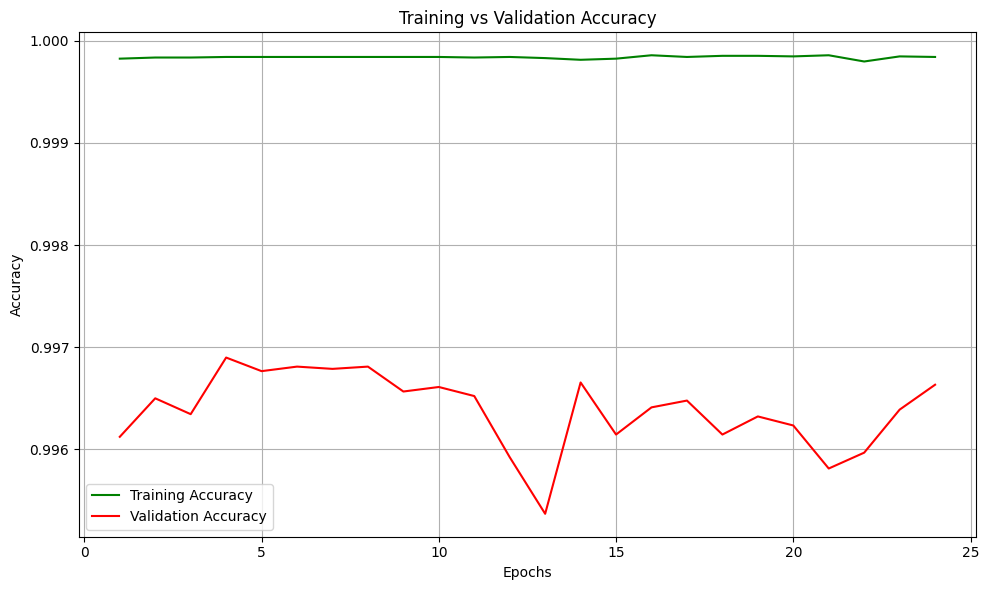

In [166]:
accuracy = history_log.history['accuracy']
val_accuracy = history_log.history['val_accuracy']

plt.figure(figsize=(10, 6))
plt.plot(epochs, accuracy, 'g-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r-', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
import pandas as pd
! wget "https://raw.githubusercontent.com/neonithinar/Intrusion-detection-cicDDOS-dataset/main/datasets/dns.csv"
! wget "https://raw.githubusercontent.com/neonithinar/Intrusion-detection-cicDDOS-dataset/main/datasets/ldap.csv"
! wget "https://raw.githubusercontent.com/neonithinar/Intrusion-detection-cicDDOS-dataset/main/datasets/mssql.csv"
! wget "https://raw.githubusercontent.com/neonithinar/Intrusion-detection-cicDDOS-dataset/main/datasets/netBIOS.csv"
! wget "https://raw.githubusercontent.com/neonithinar/Intrusion-detection-cicDDOS-dataset/main/datasets/ntp.csv"
! wget "https://raw.githubusercontent.com/neonithinar/Intrusion-detection-cicDDOS-dataset/main/datasets/snmp.csv"
! wget "https://raw.githubusercontent.com/neonithinar/Intrusion-detection-cicDDOS-dataset/main/datasets/ssdp.csv"
! wget "https://raw.githubusercontent.com/neonithinar/Intrusion-detection-cicDDOS-dataset/main/datasets/syn.csv"
! wget "https://raw.githubusercontent.com/neonithinar/Intrusion-detection-cicDDOS-dataset/main/datasets/tftp.csv"
! wget "https://raw.githubusercontent.com/neonithinar/Intrusion-detection-cicDDOS-dataset/main/datasets/udp.csv"
! wget "https://raw.githubusercontent.com/neonithinar/Intrusion-detection-cicDDOS-dataset/main/datasets/udplag.csv"

--2025-06-17 09:26:03--  https://raw.githubusercontent.com/neonithinar/Intrusion-detection-cicDDOS-dataset/main/datasets/dns.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18895635 (18M) [text/plain]
Saving to: ‘dns.csv’

dns.csv             100%[===================>]  18.02M  --.-KB/s    in 0.1s    

2025-06-17 09:26:04 (153 MB/s) - ‘dns.csv’ saved [18895635/18895635]

--2025-06-17 09:26:04--  https://raw.githubusercontent.com/neonithinar/Intrusion-detection-cicDDOS-dataset/main/datasets/ldap.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting respons

In [36]:
dfs = []
files = ['dns.csv', 'ldap.csv', 'mssql.csv', 'netBIOS.csv', 'ntp.csv', 'snmp.csv', 'ssdp.csv', 'syn.csv', 'tftp.csv', 'udp.csv', 'udplag.csv']
for file in files:
    df1 = pd.read_csv(file)
    dfs.append(df1)

In [37]:
ddos_data_test = pd.concat(dfs)

In [38]:
# @title Default title text
ddos_data_test = ddos_data_test[train_columns]
print(ddos_data_test.shape)

(440000, 85)


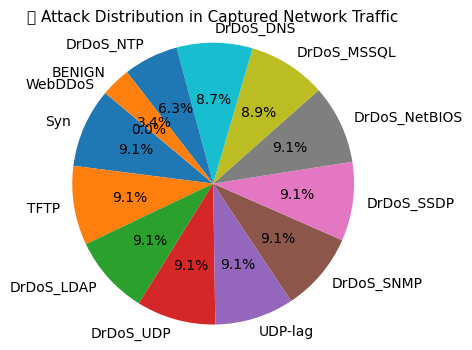

In [39]:
plot_attack_distribution(ddos_data_test)

In [40]:
preprocess_timestamps(ddos_data)

,Source IP,Source Port,Destination IP,Destination Port,Protocol,Total Length of Fwd Packets,Fwd Packet Length Min,Bwd Packet Length Min,Flow IAT Min,Bwd IAT Total,...,Avg Bwd Segment Size,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Std,Active Min,Idle Std,Idle Min,Label
Timestamp,,,,,,,,,,,,,,,,,,,,,
2017-07-07 03:30:00,-2.863587,-1.640029,0.013777,2.327831,-0.412278,-0.285426,-0.133981,-0.331193,-0.037003,-0.298606,...,-0.794893,-0.524330,-0.139372,-0.188386,-0.35585,-0.061512,-0.226482,-0.283137,-0.391071,0
2017-07-07 03:30:00,-2.799708,-1.655773,0.013777,2.337398,-0.412278,-0.287273,-0.133981,-0.212335,-0.036864,-0.298606,...,-0.789538,-0.524827,-0.079878,-0.269886,-0.35585,-0.061512,-0.226482,-0.283137,-0.391071,0
2017-07-07 03:30:00,-2.799708,-1.655773,0.013777,2.337449,-0.412278,-0.287273,-0.133981,-0.212335,-0.036939,-0.298606,...,-0.789538,-0.524827,-0.079878,-0.269886,-0.35585,-0.061512,-0.226482,-0.283137,-0.391071,0
2017-07-07 03:30:00,-2.765640,-1.640029,-0.006113,1.891022,-0.412278,-0.287273,-0.133981,-0.212335,-0.036963,-0.298606,...,-0.789538,-0.524578,-0.062978,-0.269886,-0.35585,-0.061512,-0.226482,-0.283137,-0.391071,0
2017-07-07 03:30:00,-2.748605,-1.640029,0.013777,2.327730,-0.412278,-0.285426,-0.133981,-0.331193,-0.037003,-0.298606,...,-0.794893,-0.524454,-0.139372,-0.188386,-0.35585,-0.061512,-0.226482,-0.283137,-0.391071,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-07-07 05:02:00,7.071722,-1.655773,-0.009428,2.657324,-0.412278,-0.287273,-0.133981,-0.212335,-0.036927,-0.298606,...,-0.789538,-0.492604,-0.080572,-0.269886,-0.35585,-0.061512,-0.226482,-0.283137,-0.391071,0
2017-07-07 05:02:00,7.071722,-1.655773,-0.009428,2.657526,-0.412278,-0.287273,-0.133981,-0.212335,-0.036913,-0.298606,...,-0.789538,-0.492604,-0.080572,-0.269886,-0.35585,-0.061512,-0.226482,-0.283137,-0.391071,0
2017-07-07 05:02:00,7.071722,-1.655773,-0.009428,2.657375,-0.412278,-0.287273,-0.133981,-0.212335,-0.036909,-0.298606,...,-0.789538,-0.492604,-0.080572,-0.269886,-0.35585,-0.061512,-0.226482,-0.283137,-0.391071,0


In [41]:
dropping_const_and_red_columns(ddos_data_test)

In [42]:
label_encoder=LabelEncoder()
def Encode_Label_Column_1(ddos_data):
    label_mapping = {'BENIGN': 0, 'Syn': 1, 'TFTP': 1, 'DrDoS_LDAP': 1, 'DrDoS_UDP': 1, 'UDP-lag': 1,
                 'DrDoS_SNMP': 1, 'DrDoS_SSDP': 1, 'DrDoS_NetBIOS': 1, 'DrDoS_MSSQL': 1,
                 'DrDoS_DNS': 1, 'DrDoS_NTP': 1, 'WebDDoS': 1}
    #ddos_data['Label']=label_encoder.fit_transform(ddos_data['Label'])
    ddos_data['Label'] = ddos_data['Label'].map(label_mapping)

In [43]:
Encode_Label_Column_1(ddos_data_test)
encoding_ip_srv_dst(ddos_data_test)
ddos_data_test.set_index('Timestamp', inplace=True)

In [44]:
ddos_data_test

,Source IP,Source Port,Destination IP,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
Timestamp,,,,,,,,,,,,,,,,,,,,,
2018-12-01 10:51:39.813448,37,634,162,60495,17,28415,97,0,42680.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2018-12-01 10:51:39.820842,162,634,37,60495,17,2,2,0,880.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2018-12-01 10:51:39.852499,37,634,162,46391,17,48549,200,0,88000.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2018-12-01 10:51:39.890213,37,634,162,11894,17,48337,200,0,88000.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2018-12-01 10:51:39.941151,37,634,162,27878,17,32026,200,0,88000.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-01 13:04:59.420235,37,57151,162,14047,17,1,2,0,802.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2018-12-01 13:04:59.421387,37,58534,162,39869,17,2,2,0,750.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2018-12-01 13:04:59.427021,37,59491,162,26346,17,2,2,0,750.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [45]:
ddos_data_test=ddos_data_test[final_columns]

In [46]:
non_binary_columns=ddos_data_test.columns[ddos_data_test.nunique()>2]
scale_num_features(ddos_data_test)
testX=[]
testY=[]
n_future=1
n_past=10
for i in range(n_past,len(ddos_data_test)-n_future+1):
    testX.append(ddos_data_test.iloc[i-n_past:i, :])
    testY.append(ddos_data_test.iloc[i+n_future-1:i+n_future]['Label'])
testX, testY=np.array(testX), np.array(testY)

In [47]:
non_binary_columns

Index(['Source IP', 'Source Port', 'Destination IP', 'Destination Port',
       'Protocol', 'Total Length of Fwd Packets', 'Fwd Packet Length Min',
       'Bwd Packet Length Min', 'Flow IAT Min', 'Bwd IAT Total',
       'Bwd IAT Mean', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Packet Length Mean', 'Down/Up Ratio',
       'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd',
       'min_seg_size_forward', 'Active Std', 'Active Min', 'Idle Std',
       'Idle Min'],
      dtype='object')

In [172]:
y_pred = model.predict(testX)
binary_predictions = (y_pred > 0.5).astype(int)

13750/13750 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step


In [173]:
accuracy = accuracy_score(testY, binary_predictions)
precision = precision_score(testY, binary_predictions)
recall = recall_score(testY, binary_predictions)
f1 = f1_score(testY, binary_predictions)


print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

Accuracy: 95.42%
Precision: 99.86%
Recall: 95.39%
F1 Score: 97.58%
